In [54]:
import vitaldb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy import stats
from scipy.signal import savgol_filter
# file_path = r'0019.vital'
vf = vitaldb.VitalFile('0019.vital')
vf.to_vital('0019.vital')
track_names = vitaldb.vital_trks('0019.vital')
print("Available Tracks:", track_names)



Available Tracks: ['SNUADC/CVP', 'SNUADC/ART', 'SNUADC/ECG_II', 'SNUADC/ECG_V5', 'SNUADC/PLETH', 'Solar8000/HR', 'Solar8000/ST_I', 'Solar8000/ST_II', 'Solar8000/ST_III', 'Solar8000/ST_V5', 'Solar8000/ST_AVL', 'Solar8000/ST_AVR', 'Solar8000/ST_AVF', 'Solar8000/ART_MBP', 'Solar8000/ART_SBP', 'Solar8000/ART_DBP', 'Solar8000/CVP', 'Solar8000/PLETH_SPO2', 'Solar8000/PLETH_HR', 'Solar8000/BT', 'Solar8000/VENT_RR', 'Solar8000/VENT_MV', 'Solar8000/VENT_MAWP', 'Solar8000/ETCO2', 'Solar8000/INCO2', 'Solar8000/FEO2', 'Solar8000/FIO2', 'Solar8000/NIBP_MBP', 'Solar8000/NIBP_SBP', 'Solar8000/NIBP_DBP', 'Solar8000/VENT_TV', 'Solar8000/VENT_PIP', 'Solar8000/VENT_PPLAT', 'Solar8000/VENT_INSP_TM', 'Solar8000/RR_CO2', 'Solar8000/VENT_SET_TV', 'Solar8000/VENT_SET_PCP', 'Primus/CO2', 'Primus/AWP', 'Primus/INSP_SEVO', 'Primus/EXP_SEVO', 'Primus/PAMB_MBAR', 'Primus/VENT_LEAK', 'Primus/FLOW_N2O', 'Primus/FLOW_AIR', 'Primus/FLOW_O2', 'Primus/SET_AGE', 'Primus/MAWP_MBAR', 'Primus/MV', 'Primus/SET_FIO2', 'Primus

In [2]:
track_names = ['SNUADC/ECG_II', 'SNUADC/ART']

# Initialize an empty DataFrame to hold all track data
tracks_df = pd.DataFrame()
tracks_df = vf.to_pandas(track_names, interval=1/500)


# Preview the combined DataFrame
print(tracks_df.head())

   SNUADC/ECG_II  SNUADC/ART
0            NaN         NaN
1            NaN         NaN
2            NaN         NaN
3            NaN         NaN
4            NaN         NaN


In [3]:
print(tracks_df.dtypes)


SNUADC/ECG_II    float32
SNUADC/ART       float32
dtype: object


In [4]:
# Percentage of null data for each column
null_percentage = tracks_df.isnull().mean() * 100

print(null_percentage)

SNUADC/ECG_II    0.016493
SNUADC/ART       0.016493
dtype: float64


In [5]:
# Finding the structure of dataset
print(tracks_df.info())
print(tracks_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13787741 entries, 0 to 13787740
Data columns (total 2 columns):
 #   Column         Dtype  
---  ------         -----  
 0   SNUADC/ECG_II  float32
 1   SNUADC/ART     float32
dtypes: float32(2)
memory usage: 105.2 MB
None
       SNUADC/ECG_II    SNUADC/ART
count   1.378547e+07  1.378547e+07
mean    6.273300e-02  6.916635e+01
std     1.616480e-01  2.815983e+01
min    -4.956260e+00 -4.956260e+02
25%    -1.897526e-02  5.438754e+01
50%     3.039789e-02  6.327469e+01
75%     1.192689e-01  8.302383e+01
max     5.145425e+00  4.078972e+02


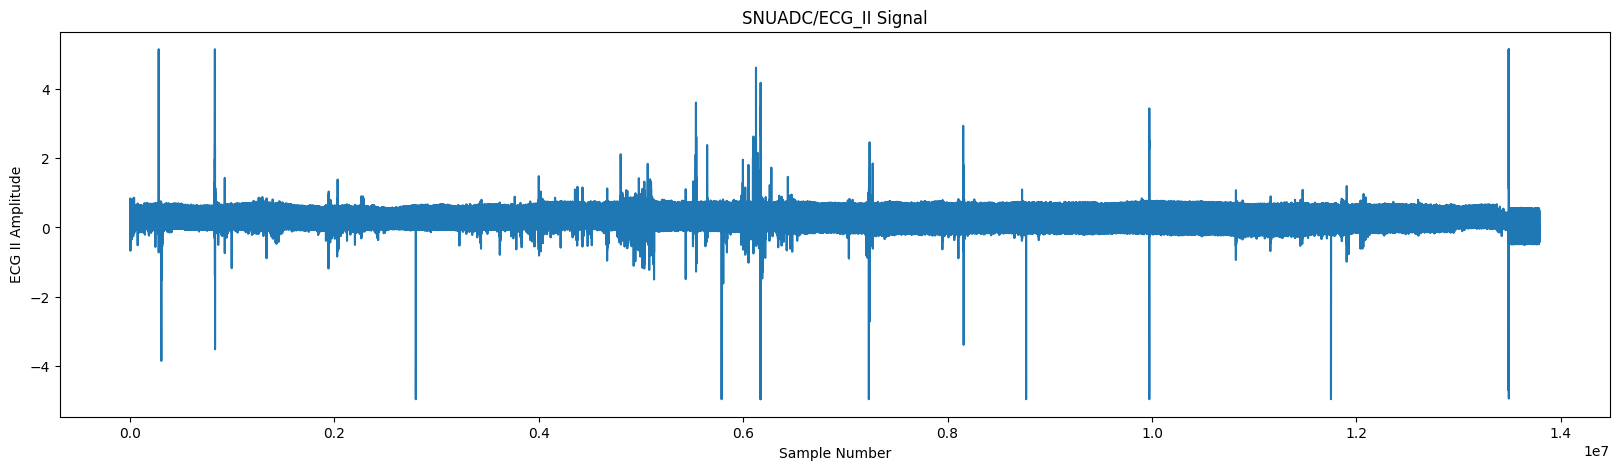

In [6]:
# Plotting one of the tracks - 'SNUADC/ECG_II'
plt.figure(figsize=(20, 5))
plt.plot(tracks_df['SNUADC/ECG_II']) 
plt.title('SNUADC/ECG_II Signal')
plt.xlabel('Sample Number')
plt.ylabel('ECG II Amplitude')
plt.show()

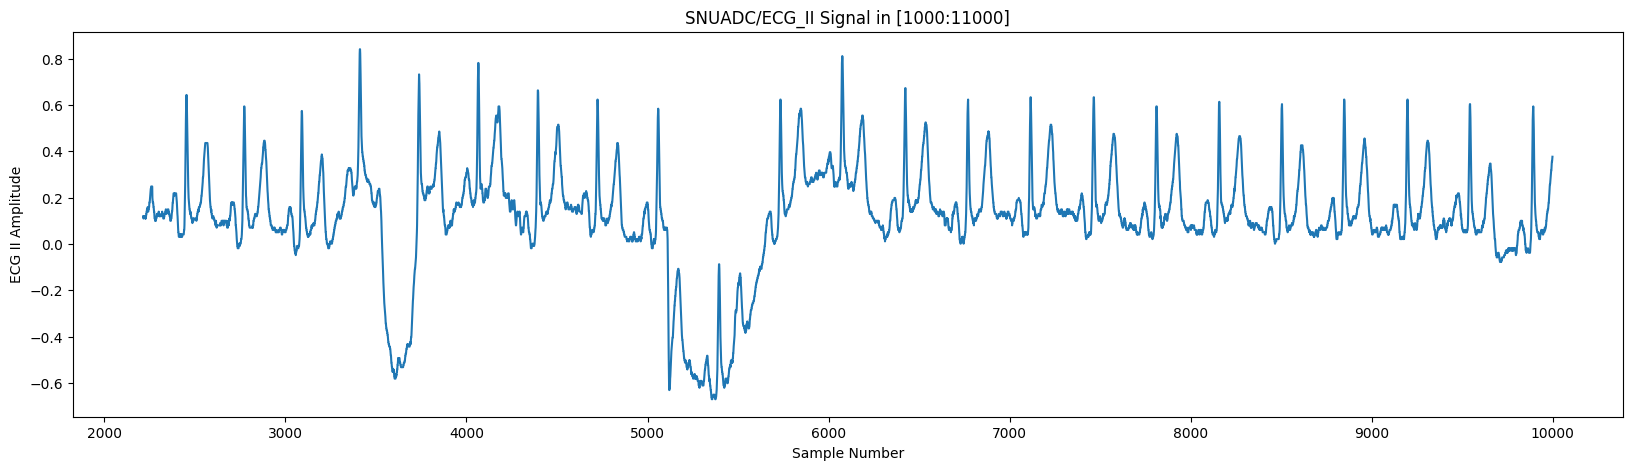

In [7]:
# Plotting one of the tracks - 'SNUADC/ECG_II'
plt.figure(figsize=(20, 5))
plt.plot(tracks_df['SNUADC/ECG_II'][1000:10000]) 
plt.title('SNUADC/ECG_II Signal in [1000:11000]')
plt.xlabel('Sample Number')
plt.ylabel('ECG II Amplitude')
plt.show()

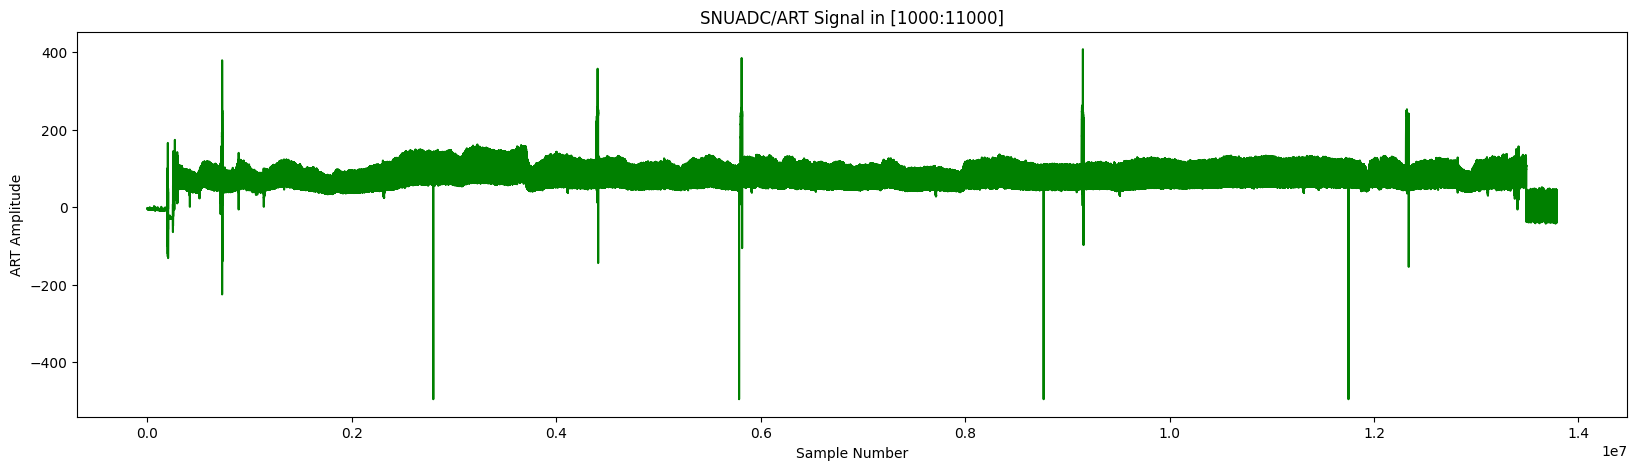

In [8]:
# Plotting one of the tracks - 'SNUADC/ECG_II'
plt.figure(figsize=(20, 5))
plt.plot(tracks_df['SNUADC/ART'], color='g') 
plt.title('SNUADC/ART Signal in [1000:11000]')
plt.xlabel('Sample Number')
plt.ylabel('ART Amplitude')
plt.show()

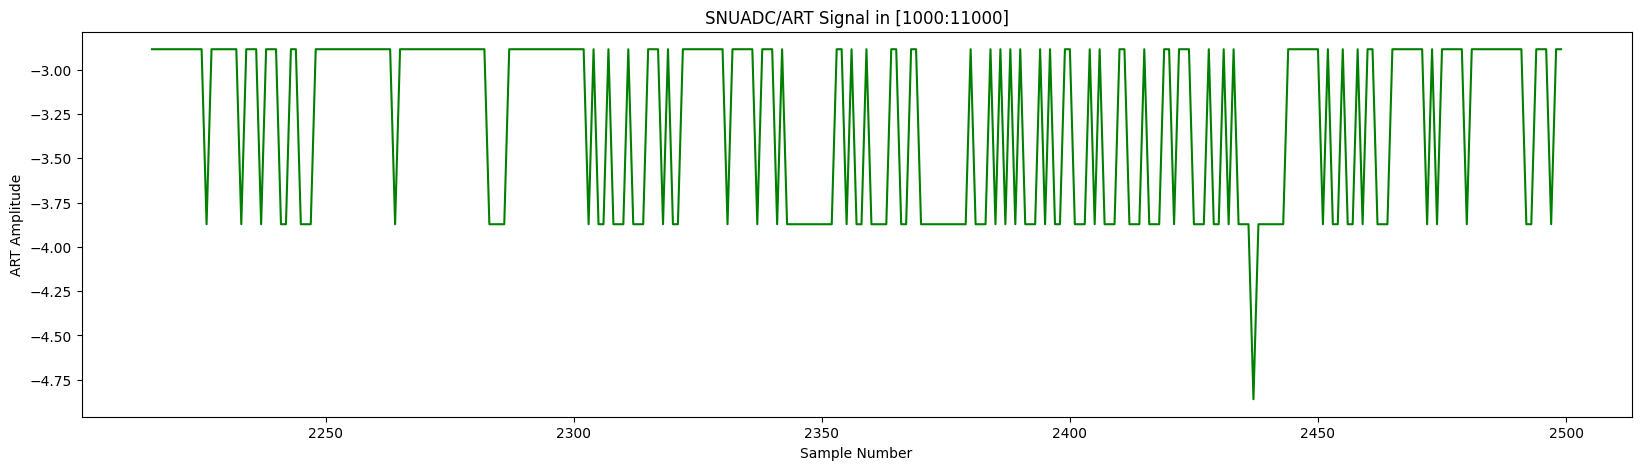

In [9]:
# Plotting one of the tracks - 'SNUADC/ECG_II'
plt.figure(figsize=(20, 5))
plt.plot(tracks_df['SNUADC/ART'][2000:2500], color='g') 
plt.title('SNUADC/ART Signal in [1000:11000]')
plt.xlabel('Sample Number')
plt.ylabel('ART Amplitude')
plt.show()

We use interpolation method for handling missing or negative data in this dataset because it provides a methodologically sound means of preserving the continuity and integrity of time-series data, which is essential for conducting accurate and meaningful analysis of the relationships between vital signs in surgical patients.

In [10]:
# Count missing values
missing_values = tracks_df.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 SNUADC/ECG_II    2274
SNUADC/ART       2274
dtype: int64


In [11]:

# Count negative values for each column
negative_values_count = (tracks_df < 0).sum()

Replacing negative arterial blood pressure readings with NaN (because blood pressure cannot have negative data) before applying linear interpolation nearby neighboring data points to correct these values thus preserving integrity of our dataset.

Missing values before interpolation:
 SNUADC/ECG_II      2274
SNUADC/ART       389919
dtype: int64
Missing values after interpolation:
 SNUADC/ECG_II     2215
SNUADC/ART       65060
dtype: int64


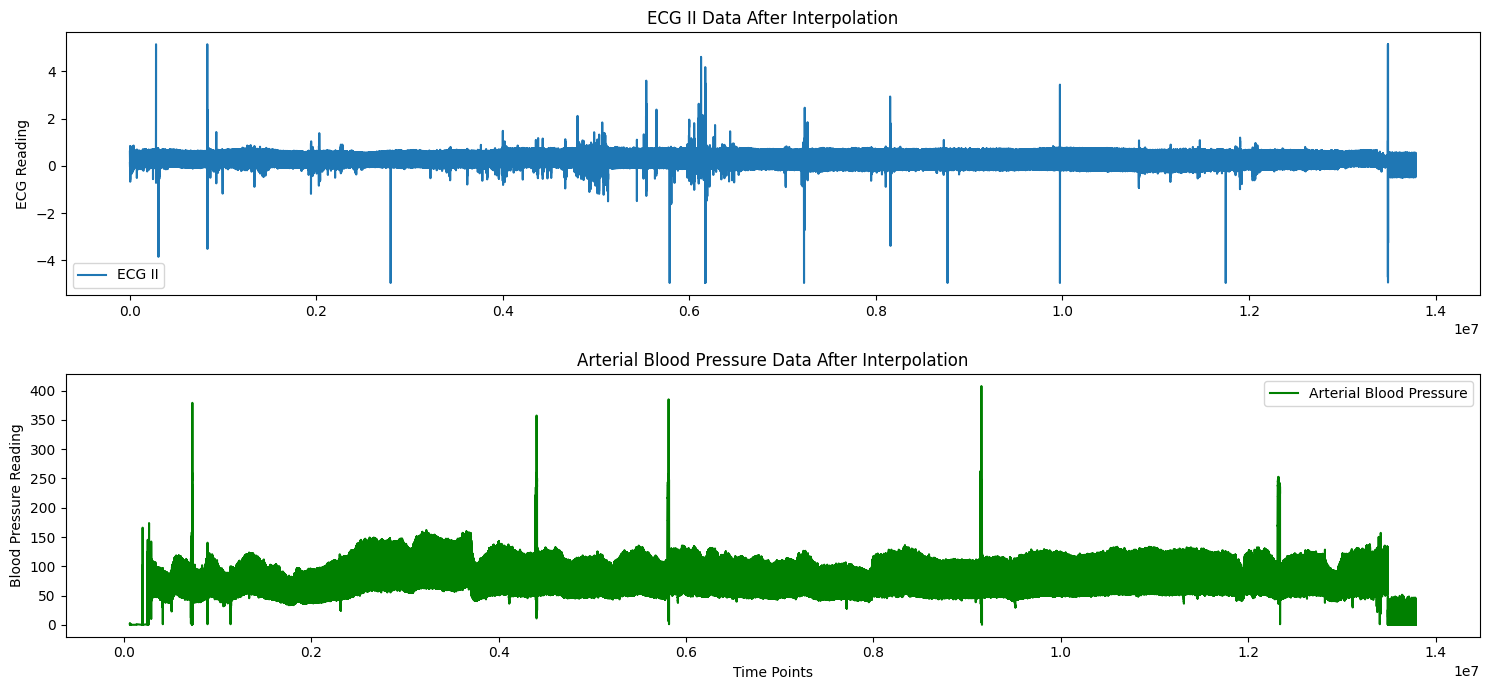

In [12]:
# Replace negative values in the arterial blood pressure column with NaN, but leave ECG data as is
tracks_df.loc[tracks_df['SNUADC/ART'] < 0, 'SNUADC/ART'] = pd.NA

# Check for missing values before interpolation
print("Missing values before interpolation:\n", tracks_df.isnull().sum())

# Interpolate missing values (this will not affect ECG negative values)
tracks_df.interpolate(method='linear', limit_direction='forward', inplace=True)

# Check for missing values after interpolation
print("Missing values after interpolation:\n", tracks_df.isnull().sum())

# Optional: Plotting to verify the interpolation visually
# Plot a small segment of the data as an example
plt.figure(figsize=(15, 7))

plt.subplot(2, 1, 1)
plt.plot(tracks_df['SNUADC/ECG_II'], label='ECG II')
plt.legend()
plt.title('ECG II Data After Interpolation')
plt.ylabel('ECG Reading')

plt.subplot(2, 1, 2)
plt.plot(tracks_df['SNUADC/ART'], label='Arterial Blood Pressure', color='g')
plt.legend()
plt.title('Arterial Blood Pressure Data After Interpolation')
plt.xlabel('Time Points')
plt.ylabel('Blood Pressure Reading')

plt.tight_layout()
plt.show()

In [13]:
# Outliers
def find_outliers_iqr(df, column):
    """
    Identify outliers using the IQR method for a specific column in a DataFrame.

    Parameters:
    - df: pandas.DataFrame
    - column: str, the name of the column to analyze

    Returns:
    - A boolean series where True indicates an outlier.
    """
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
    return outliers

# Apply the function to our data
ecg_outliers = find_outliers_iqr(tracks_df, 'SNUADC/ECG_II')
art_outliers = find_outliers_iqr(tracks_df, 'SNUADC/ART')

# Count outliers
ecg_outliers_count = ecg_outliers.sum()
art_outliers_count = art_outliers.sum()
print(f"Number of ECG outliers: {ecg_outliers_count}")
print(f"Number of Arterial Blood Pressure outliers: {art_outliers_count}")

Number of ECG outliers: 954295
Number of Arterial Blood Pressure outliers: 689962


I chose the IQR method for identifying outliers because it effectively handles the variability in medical data like ECG and blood pressure readings, recognize extreme values without relying on distribution assumptions. This way ensures that outlier handling is statistically robust and preserving vital physiological insight.

Number of ECG outliers: 954295
Number of Arterial Blood Pressure outliers: 689962


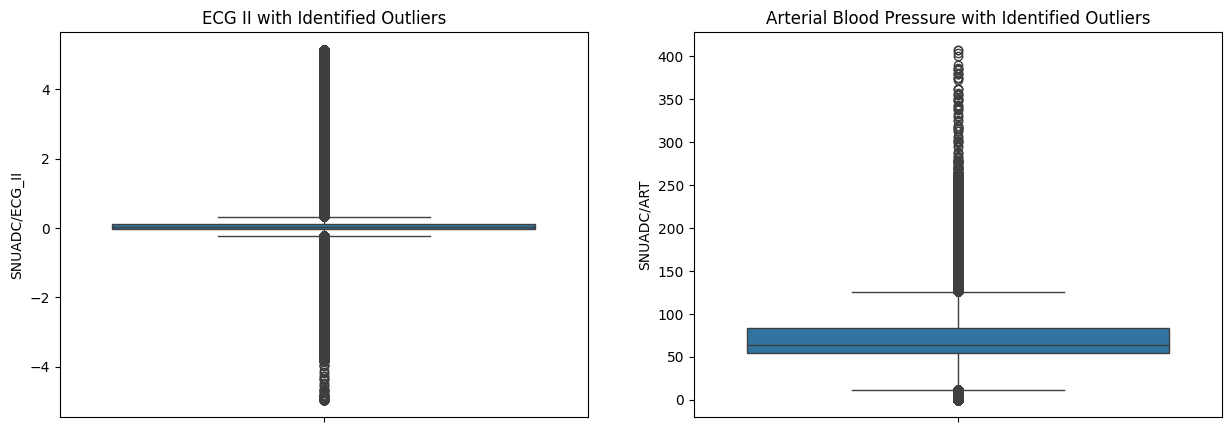

In [14]:
# Function to calculate lower and upper thresholds for outliers based on IQR
def calculate_outlier_thresholds(data, multiplier=3):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (iqr * multiplier)
    upper_bound = q3 + (iqr * multiplier)
    return lower_bound, upper_bound

# Function to identify outliers
def identify_outliers(data, lower_bound, upper_bound):
    return (data < lower_bound) | (data > upper_bound)

# For Arterial Blood Pressure, based on clinical relevance, negative values are not possible
# Replace negative values with NaN to indicate likely measurement errors
tracks_df['SNUADC/ART'] = tracks_df['SNUADC/ART'].apply(lambda x: np.nan if x < 0 else x)

# Calculate thresholds for outliers with a more aggressive threshold (multiplier=3)
ecg_lower_bound, ecg_upper_bound = calculate_outlier_thresholds(tracks_df['SNUADC/ECG_II'])
art_lower_bound, art_upper_bound = calculate_outlier_thresholds(tracks_df['SNUADC/ART'])

# Identify outliers
ecg_outliers = identify_outliers(tracks_df['SNUADC/ECG_II'], ecg_lower_bound, ecg_upper_bound)
art_outliers = identify_outliers(tracks_df['SNUADC/ART'], art_lower_bound, art_upper_bound)
print(f"Number of ECG outliers: {ecg_outliers_count}")
print(f"Number of Arterial Blood Pressure outliers: {art_outliers_count}")
# Visualize the identified outliers
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=tracks_df['SNUADC/ECG_II'])
plt.title('ECG II with Identified Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=tracks_df['SNUADC/ART'])
plt.title('Arterial Blood Pressure with Identified Outliers')
plt.show()

The first outlier detection method provides greater flexibility and customization with adjustable IQR multipliers suitable for diverse datasets, but it is more complex and modular, enhancing reusability at the cost of increased complexity. Conversely, the second method is straightforward and easy to use for quick outlier checks, ideal for standard analysis without the need for extensive customization.

In [15]:
# Correcting erroneous negative blood pressure values
tracks_df['SNUADC/ART'] = tracks_df['SNUADC/ART'].apply(lambda x: np.nan if x < 0 else x)
# Simple example - smoothing (Consider domain-specific methods)
tracks_df['SNUADC/ECG_II'] = tracks_df['SNUADC/ECG_II'].rolling(window=5).mean()

In [16]:
# Computing median and IQR as robust statistics
median_ecg = tracks_df['SNUADC/ECG_II'].median()
iqr_ecg = tracks_df['SNUADC/ECG_II'].quantile(0.75) - tracks_df['SNUADC/ECG_II'].quantile(0.25)

print(f"Median ECG II: {median_ecg}, IQR ECG II: {iqr_ecg}")


median_ecg = tracks_df['SNUADC/ART'].median()
iqr_ecg = tracks_df['SNUADC/ART'].quantile(0.75) - tracks_df['SNUADC/ART'].quantile(0.25)

print(f"Median ART: {median_ecg}, IQR ART: {iqr_ecg}")

Median ECG II: 0.03434762954711914, IQR ECG II: 0.14416866302490233
Median ART: 63.274688720703125, IQR ART: 28.63629150390625


Pearson Correlation Coefficient:
               SNUADC/ECG_II  SNUADC/ART
SNUADC/ECG_II       1.000000    0.222699
SNUADC/ART          0.222699    1.000000


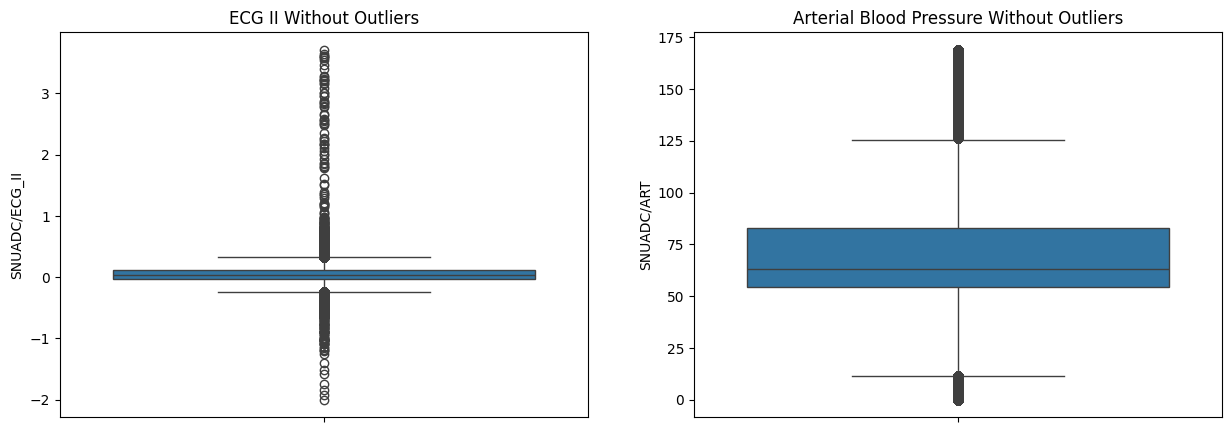

In [17]:
# First, create a new DataFrame without the outliers
tracks_df_no_outliers = tracks_df[~ecg_outliers & ~art_outliers]

# Now, drop any remaining NaN values from the DataFrame
cleaned_df = tracks_df_no_outliers.dropna(subset=['SNUADC/ECG_II', 'SNUADC/ART'])

# If we want to proceed with the correlation analysis now, make sure 'cleaned_df' is used
correlation_matrix = cleaned_df[['SNUADC/ECG_II', 'SNUADC/ART']].corr()
print("Pearson Correlation Coefficient:")
print(correlation_matrix)

# Visualizing the cleaned data without outliers
plt.figure(figsize=(15, 5))

# ECG II without outliers
plt.subplot(1, 2, 1)
sns.boxplot(y=cleaned_df['SNUADC/ECG_II'])
plt.title('ECG II Without Outliers')

# Arterial Blood Pressure without outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=cleaned_df['SNUADC/ART'])
plt.title('Arterial Blood Pressure Without Outliers')

plt.show()

The Pearson correlation analysis between "SNUADC/ECG_II" and "SNUADC/ART" reveals a weak positive correlation coefficient of 0.221753. This indicates a slight linear relationship where increases in one variable are weakly associated with increases in the other, though the relationship is not strong enough to imply any significant or practical predictive power. Further analysis, including visualizations and statistical testing, is recommended to better understand the dynamics of this relationship and to determine its statistical significance.

In [18]:
# Extract the correlation value from the matrix
r = correlation_matrix.loc['SNUADC/ECG_II', 'SNUADC/ART']

# Determine the number of observations in the cleaned DataFrame
n = cleaned_df.shape[0]

# Calculate the t-statistic for the correlation
t_statistic = r * np.sqrt((n - 2) / (1 - r**2))

# Degrees of freedom
df = n - 2

# Calculate the p-value
p_value = stats.t.sf(np.abs(t_statistic), df) * 2  # Two-tailed p-value

# Print the t-statistic, degrees of freedom, and p-value
print(f"t-Statistic: {t_statistic}")
print(f"Degrees of Freedom: {df}")
print(f"p-Value: {p_value}")

alpha = 0.05  
if p_value < alpha:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")


t-Statistic: 840.9419624718354
Degrees of Freedom: 13552077
p-Value: 0.0
The correlation is statistically significant.


In [19]:
# Windoing
window_length = 5  
polyorder = 2     

# Apply Savitzky-Golay filter
cleaned_df['SG_Smoothed_ECG_II'] = savgol_filter(cleaned_df['SNUADC/ECG_II'], window_length, polyorder)
cleaned_df['SG_Smoothed_ART'] = savgol_filter(cleaned_df['SNUADC/ART'], window_length, polyorder)

# Display the smoothed data
print(cleaned_df[['SNUADC/ECG_II', 'SG_Smoothed_ECG_II', 'SNUADC/ART', 'SG_Smoothed_ART']])
print(cleaned_df.shape)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\2602146546.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['SG_Smoothed_ECG_II'] = savgol_filter(cleaned_df['SNUADC/ECG_II'], window_length, polyorder)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\2602146546.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['SG_Smoothed_ART'] = savgol_filter(cleaned_df['SNUADC/ART'], window_length, polyorder)


          SNUADC/ECG_II  SG_Smoothed_ECG_II  SNUADC/ART  SG_Smoothed_ART
65060          0.022498            0.021652    1.064880         0.613471
65061          0.034348            0.035363    1.064880         1.883059
65062          0.044222            0.046253    2.052338         2.306255
65063          0.058047            0.055507    3.039795         2.024125
65064          0.058047            0.059062    0.077423         1.262372
...                 ...                 ...         ...              ...
13787736      -0.078223           -0.072975   22.788910        24.820266
13787737       0.081746            0.080222   11.926910        13.450405
13787738       0.218015            0.211921   11.926910        10.995882
13787739       0.253563            0.241037   11.926910        10.375196
13787740       0.182466            0.189745   11.926910        12.857939

[13552079 rows x 4 columns]
(13552079, 4)


The Savitzky-Golay filter is generally preferred to smoothing ECG and ART data because it preserves the shape and features of the waveform, which are crucial for identifying rhythms and diagnosing abnormalities in ECG signals. Also for ART, it helps maintain the integrity of sharp systolic peaks and diastolic troughs, which are essential for accurate blood pressure monitoring and analysis.

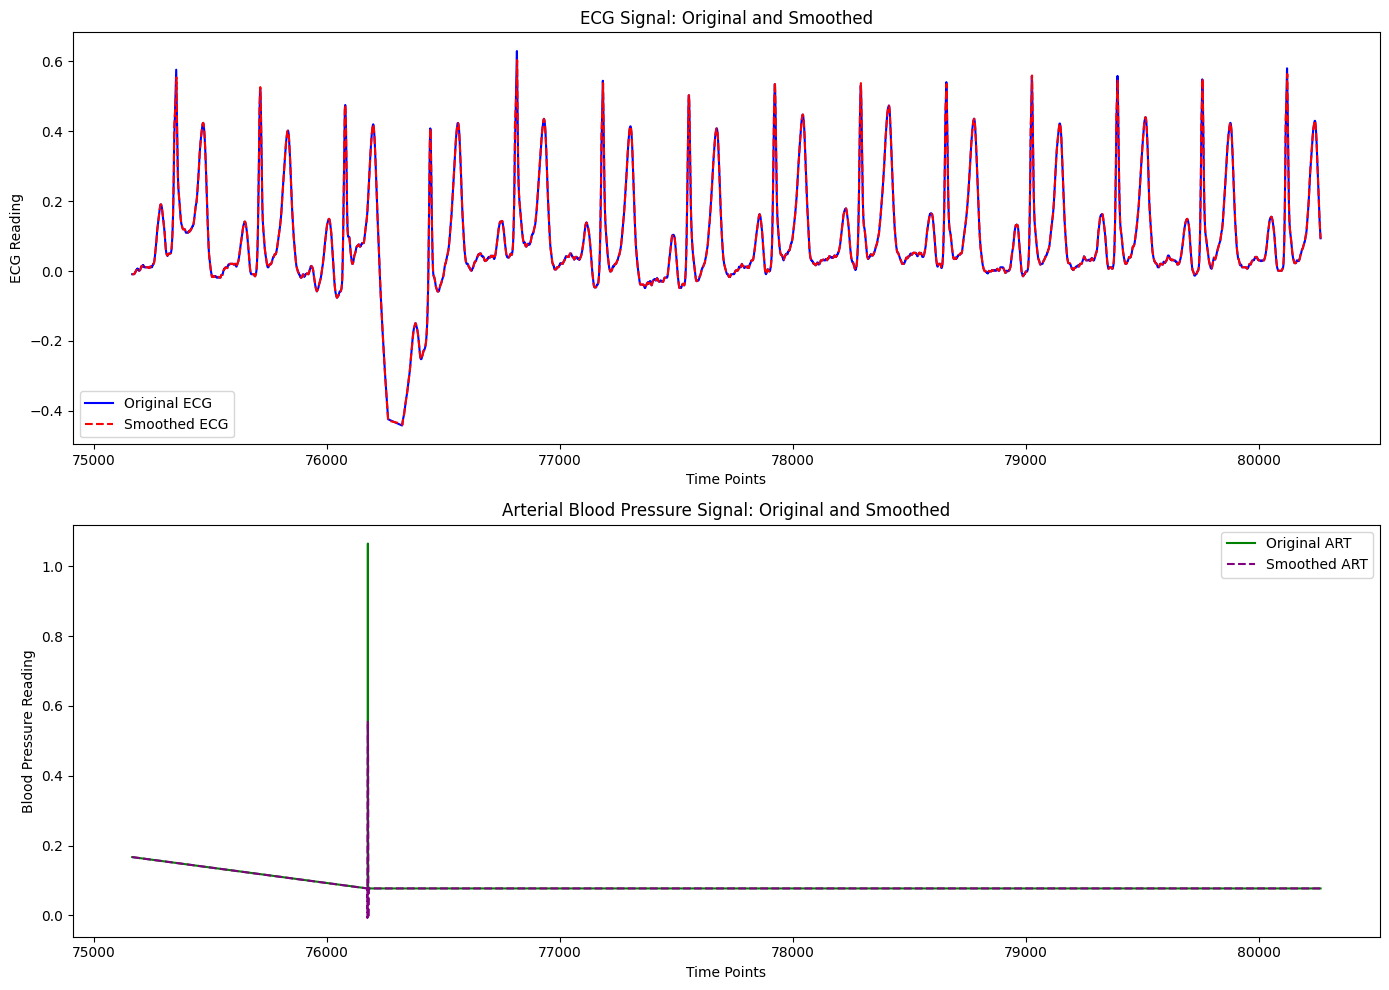

In [30]:
# Define the range of indices to plot
start_index = 10000  # Start index of the range
end_index = 15000    # End index of the range

# Set up the figure for plotting
plt.figure(figsize=(14, 10))

# Plot for ECG data
plt.subplot(2, 1, 1)
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ECG_II'][start_index:end_index], label='Original ECG', color='blue')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index], label='Smoothed ECG', color='red', linestyle='--')
plt.title('ECG Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('ECG Reading')
plt.legend()

# Plot for ART data
plt.subplot(2, 1, 2)
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ART'][start_index:end_index], label='Original ART', color='green')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ART'][start_index:end_index], label='Smoothed ART', color='purple', linestyle='--')
plt.title('Arterial Blood Pressure Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('Blood Pressure Reading')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


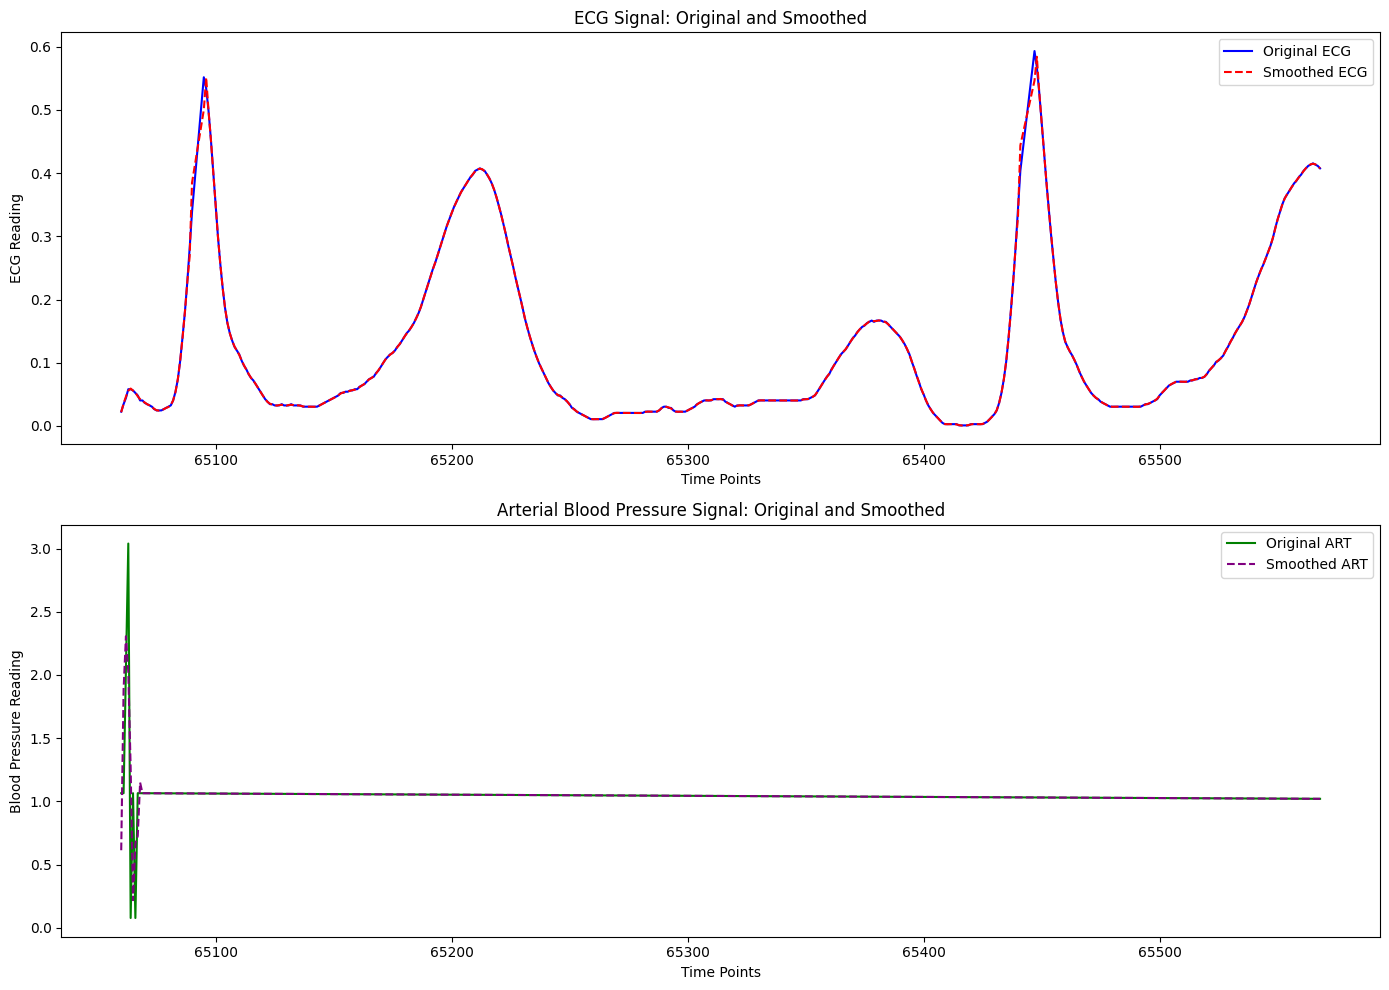

In [34]:
# Plot the original and smoothed signals
import matplotlib.pyplot as plt

# Define start and end indices for the data segment you want to plot
start_index = 0  # Starting index of the data slice
end_index = 500  # Ending index of the data slice, ensure this is within the DataFrame's range

# Set up the figure for plotting
plt.figure(figsize=(14, 10))

# Plot for ECG data
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first subplot
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ECG_II'][start_index:end_index], label='Original ECG', color='blue')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index], label='Smoothed ECG', color='red', linestyle='--')
plt.title('ECG Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('ECG Reading')
plt.legend()

# Plot for ART data
plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ART'][start_index:end_index], label='Original ART', color='green')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ART'][start_index:end_index], label='Smoothed ART', color='purple', linestyle='--')
plt.title('Arterial Blood Pressure Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('Blood Pressure Reading')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


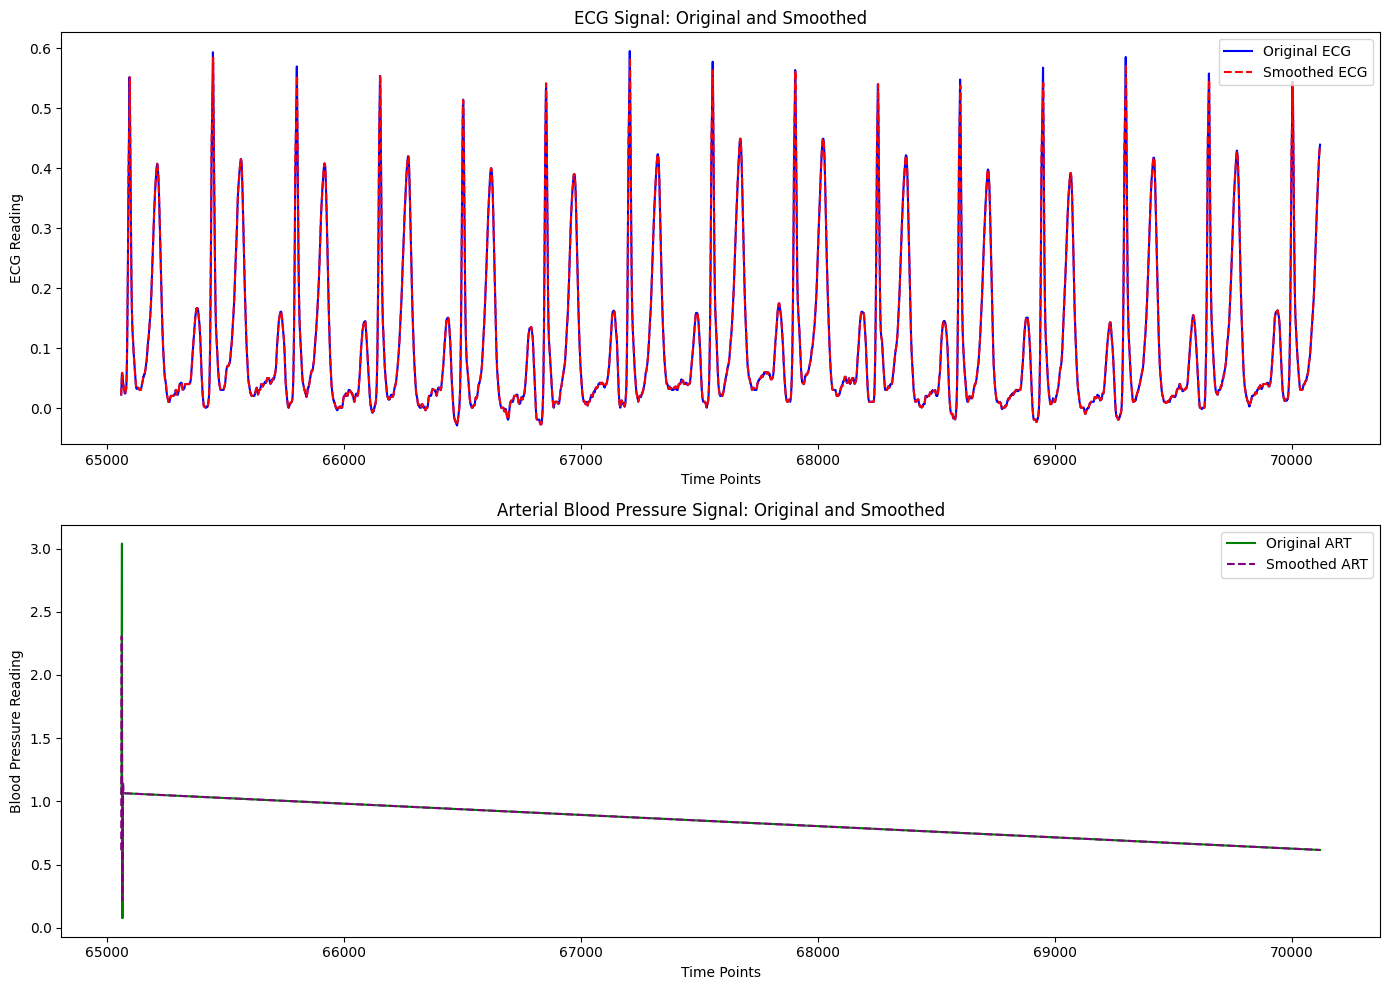

In [39]:
import matplotlib.pyplot as plt

# Define the range you want to view
start_index = 0  # Start of the range
end_index = 5000  # End of the range, make sure this is within the bounds of your DataFrame

# Check if the end index is within the DataFrame's range to prevent out-of-bounds error
if end_index > len(cleaned_df):
    end_index = len(cleaned_df)  # Adjust end_index to be the last element if out-of-bounds

# Set up the figure for plotting
plt.figure(figsize=(14, 10))

# Plot for ECG data
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first subplot
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ECG_II'][start_index:end_index], label='Original ECG', color='blue')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index], label='Smoothed ECG', color='red', linestyle='--')
plt.title('ECG Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('ECG Reading')
plt.legend()

# Plot for ART data
plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SNUADC/ART'][start_index:end_index], label='Original ART', color='green')
plt.plot(cleaned_df.index[start_index:end_index], cleaned_df['SG_Smoothed_ART'][start_index:end_index], label='Smoothed ART', color='purple', linestyle='--')
plt.title('Arterial Blood Pressure Signal: Original and Smoothed')
plt.xlabel('Time Points')
plt.ylabel('Blood Pressure Reading')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


the ECG plot has regular peaks indicative of a normal heart rhythm, overlaid with a smoothed line that highlights the main waveform pattern; the arterial blood pressure plot where the original and smoothed lines are virtually indistinguishable, suggesting a flatline with no detectable pulsatile activity, possibly due to an error in data collection or processing.

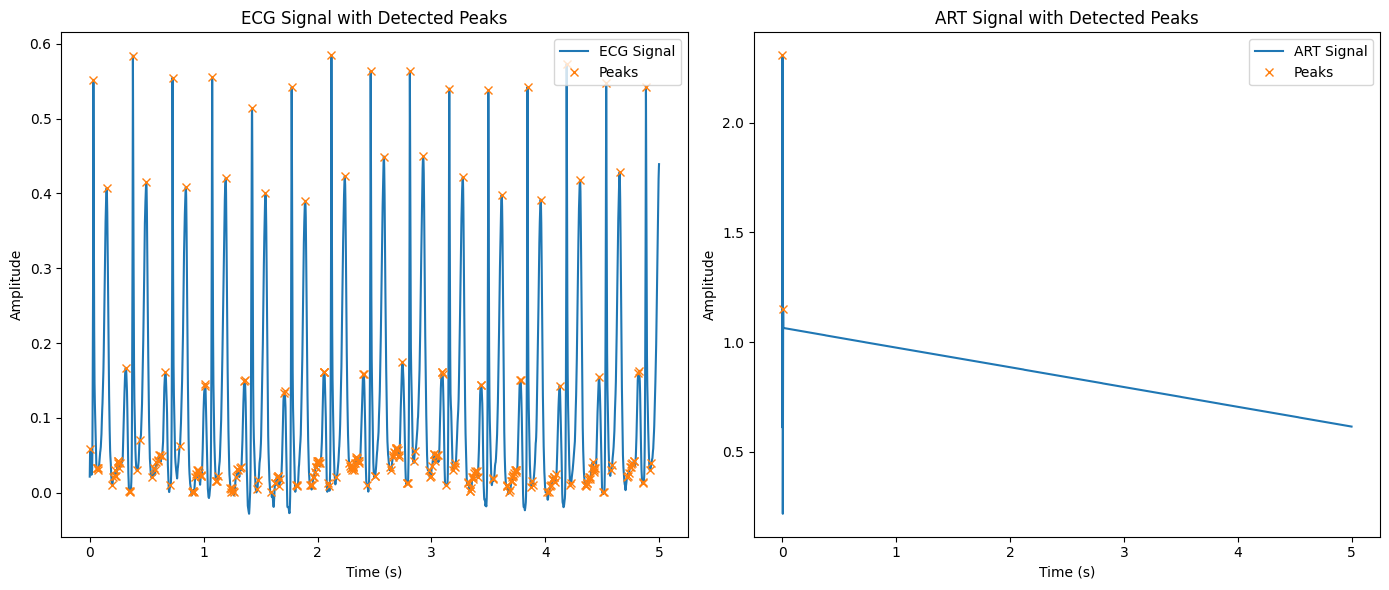

In [49]:

sampling_rate = 1000  # Example: 1000 Hz (1 kHz), replace with your actual rate

# Create a time vector for the segment being plotted
t_segment = np.linspace(0, (end_index - start_index) / sampling_rate, num=(end_index - start_index), endpoint=False)

# Adjust peak finding to use the correctly sliced data
ecg_peaks, _ = find_peaks(cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index], height=0)
art_peaks, _ = find_peaks(cleaned_df['SG_Smoothed_ART'][start_index:end_index], height=0)

# Plotting the signals with detected peaks
plt.figure(figsize=(14, 6))

# Plot for ECG
plt.subplot(1, 2, 1)
plt.plot(t_segment, cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index], label='ECG Signal')
# Use relative indices to plot peaks within the plotted segment
plt.plot(t_segment[ecg_peaks], cleaned_df['SG_Smoothed_ECG_II'][start_index:end_index].iloc[ecg_peaks], 'x', label='Peaks')
plt.title('ECG Signal with Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()

# Plot for ART
plt.subplot(1, 2, 2)
plt.plot(t_segment, cleaned_df['SG_Smoothed_ART'][start_index:end_index], label='ART Signal')
# Use relative indices to plot peaks within the plotted segment
plt.plot(t_segment[art_peaks], cleaned_df['SG_Smoothed_ART'][start_index:end_index].iloc[art_peaks], 'x', label='Peaks')
plt.title('ART Signal with Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()


Both plots are labeled with time in seconds on the x-axis and amplitude on the y-axis, providing a clear representation of the time and magnitude of each signal. The consistent detection of peaks in the ECG suggests reliable data, while the ART signal suggests either a lack of pulsatile activity or a need for further review of the peak detection algorithm or data quality.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\767046249.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['Time'] = pd.date_range(start='2021-01-01', periods=len(cleaned_df), freq='T')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\767046249.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.asfreq('T').fillna(method='ffill')  # 'T' for minutely data; adjust as needed


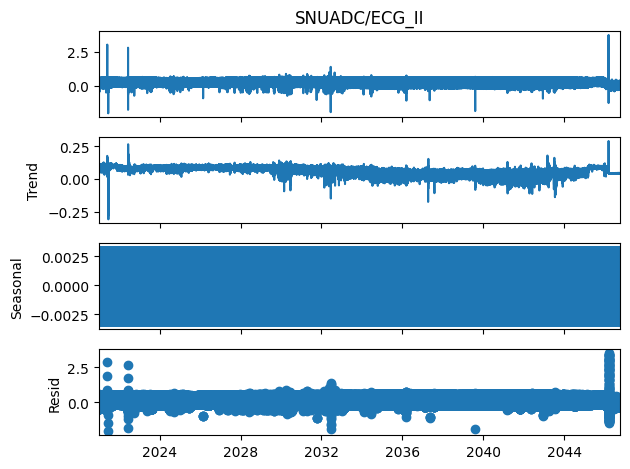

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose


# Create a datetime index if our dataframe doesn't already have one
cleaned_df['Time'] = pd.date_range(start='2021-01-01', periods=len(cleaned_df), freq='T')
cleaned_df.set_index('Time', inplace=True)

# Selecting a column to decompose
data = cleaned_df['SNUADC/ECG_II']

# Handling any missing data
data = data.asfreq('T').fillna(method='ffill')  # 'T' for minutely data; adjust as needed

# Try manually setting the period if the data frequency is minutely and you expect daily seasonality
period = 1440  # Number of minutes in a day

# Decompose the time series with the manual period
result = seasonal_decompose(data, model='additive', period=period)  # Use 'multiplicative' if the seasonal variation increases with the level of the time series

# Plotting the decomposed components
result.plot()
plt.show()



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\4032863808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['Time'] = pd.date_range(start='2021-01-01', periods=len(cleaned_df), freq='T')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6396\4032863808.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.asfreq('T').fillna(method='ffill')  # 'T' for minutely data; adjust as needed


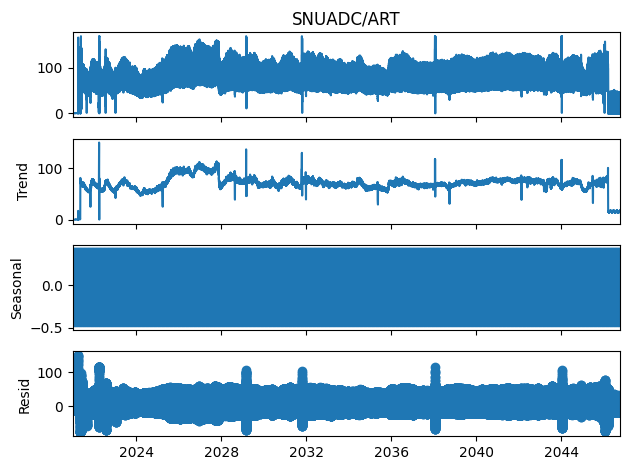

In [53]:
# Create a datetime index if our dataframe doesn't already have one
cleaned_df['Time'] = pd.date_range(start='2021-01-01', periods=len(cleaned_df), freq='T')
cleaned_df.set_index('Time', inplace=True)

# Selecting a column to decompose
data = cleaned_df['SNUADC/ART']

# Handling any missing data
data = data.asfreq('T').fillna(method='ffill')  # 'T' for minutely data; adjust as needed

# Try manually setting the period if the data frequency is minutely and you expect daily seasonality
period = 1440  # Number of minutes in a day

# Decompose the time series with the manual period
result = seasonal_decompose(data, model='additive', period=period)  # Use 'multiplicative' if the seasonal variation increases with the level of the time series

# Plotting the decomposed components
result.plot()
plt.show()



The decomposition plot for ECG data, showing a largely stable trend with minor fluctuations, negligible seasonality, and random noise evident in the residuals. The decomposition of ART data, with a pronounced erratic trend, no clear seasonality, and significant variation in the residuals, suggesting a more complex and possibly non-stationary signal.